# HydraMultiRocketPlus za dataset *Otkrivanje transakcijskih prijevara*
 https://www.kaggle.com/competitions/dap-fer2025

1. Univarijatni signal (samo iznosi)
2. Multivarijatni signal (datum, lag, roll)

## 1. Univarijatni signal

X shape: (337, 1, 28)
y shape: (337,)
Train samples: 276
Test samples: 61
HydraMultiRocketPlus(
  (backbone): HydraMultiRocketBackbonePlus(
    (hydra): HydraBackbonePlus()
    (multirocket): MultiRocketBackbonePlus(
      (branch_x): MultiRocketFeaturesPlus()
      (branch_x_diff): MultiRocketFeaturesPlus()
    )
  )
  (head): Sequential(
    (0): fastai.layers.Flatten(full=False)
    (1): BatchNorm1d(51776, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Linear(in_features=51776, out_features=1, bias=True)
  )
)


epoch,train_loss,valid_loss,mae,_rmse,time
0,301513.375000,324714.781250,471.800720,569.837463,00:02
1,290112.250000,301794.656250,445.781281,549.358398,00:02
2,232995.921875,194395.906250,332.055817,440.903473,00:02
3,125262.179688,127293.687500,300.268066,356.782410,00:02
4,87026.718750,125167.851562,292.184753,353.790680,00:02
5,70015.171875,111254.390625,270.794830,333.548187,00:01
6,62626.593750,137695.109375,310.653839,371.072906,00:01
7,56878.730469,155346.671875,334.494507,394.140442,00:01
8,49918.054688,165811.484375,344.021271,407.199554,00:01
9,46413.714844,164435.390625,338.378021,405.506348,00:01


Better model found at epoch 0 with valid_loss value: 324714.78125.
Better model found at epoch 1 with valid_loss value: 301794.65625.
Better model found at epoch 2 with valid_loss value: 194395.90625.
Better model found at epoch 3 with valid_loss value: 127293.6875.
Better model found at epoch 4 with valid_loss value: 125167.8515625.
Better model found at epoch 5 with valid_loss value: 111254.390625.


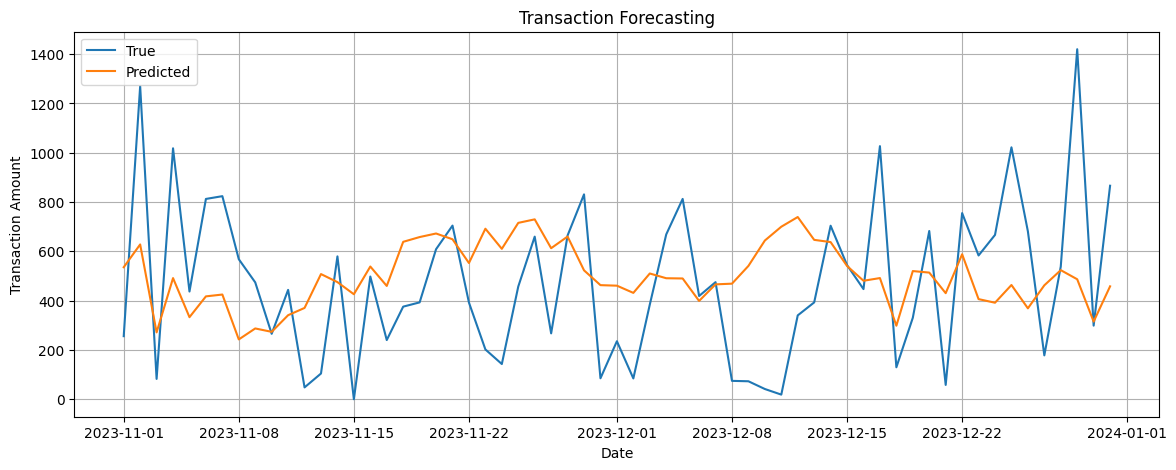

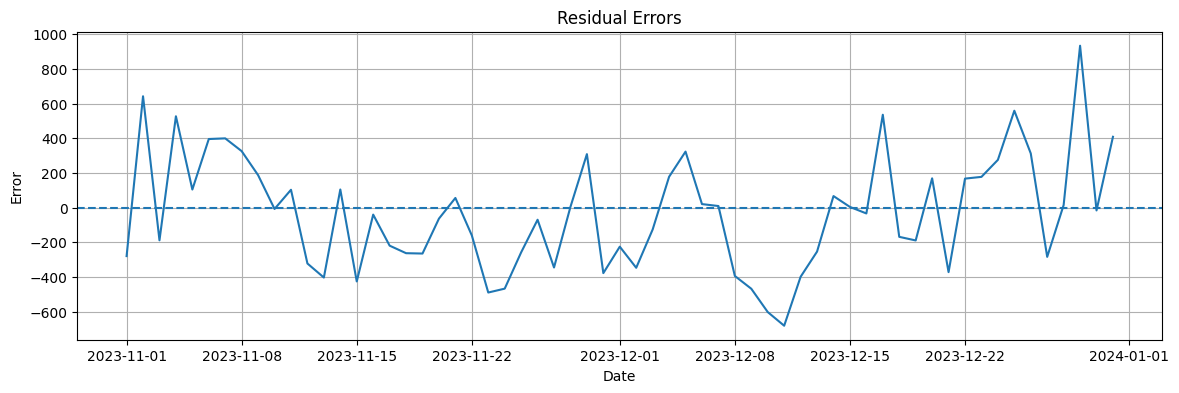

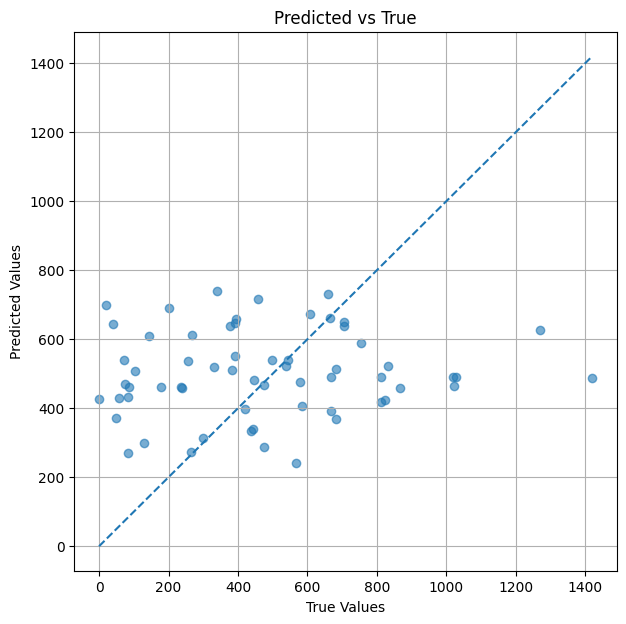

Better model found at epoch 0 with valid_loss value: 270.7948303222656.

MAE : 270.7948
RMSE: 333.5482


In [1]:
from tsai.all import *
from fastai.callback.tracker import SaveModelCallback

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

set_seed(42, reproducible=True)



df = pd.read_csv('dataset.csv')

# ciscenje
df = df[df['User_ID'] != 'USER_0007'].copy()
df['Location'] = df['Location'].replace('Lndn', 'London')
df = df.loc[df['Transaction_Amount'] > 0, :].copy()


df["Timestamp"] = pd.to_datetime(df["Timestamp"])



# AGREGACIJA
daily = (
    df[
        (df["Transaction_Type"] == "Online") &
        (df["Location"] == "London") &
        (df["Fraud_Label"] == 0)
    ]
    .groupby(df["Timestamp"].dt.date)["Transaction_Amount"]
    .sum()
    .reset_index()
)

daily.columns = ["Date", "Total_Transaction"]

daily["Date"] = pd.to_datetime(daily["Date"])


daily = (
    daily.set_index("Date")
    .asfreq("D", fill_value=0)
    .reset_index()
)





values_raw = daily["Total_Transaction"].values

# FORECASTING WINDOWS

window_size = 28    #isprobane razlicite velicine, ova daje najbolje rez

X = []
y = []
dates = []

for i in range(len(values_raw) - window_size):

    X.append(values_raw[i:i+window_size])

    y.append(values_raw[i+window_size])

    dates.append(daily["Date"].iloc[i+window_size])

X = np.array(X)
y = np.array(y)
#dates = np.array(dates)
dates = pd.to_datetime(dates)

# tsai expects:
# (samples, channels, timesteps)

X = X[:, np.newaxis, :]

print("X shape:", X.shape)
print("y shape:", y.shape)


#split
split_date = pd.Timestamp('2023-11-01')

train_idx = np.where(dates < split_date)[0]
test_idx = np.where(dates >= split_date)[0]

splits = (train_idx, test_idx)



print("Train samples:", len(train_idx))
print("Test samples:", len(test_idx))



dls = get_ts_dls(
    X,
    y,
    splits=splits,
    bs=5    #bolje radi za manji batch
)



model = HydraMultiRocketPlus(
    c_in=1,
    c_out=1,
    seq_len=window_size
)

print(model)


learn = Learner(
    dls,
    model,
    loss_func=MSELossFlat(),
    metrics=[mae, rmse],
    cbs=SaveModelCallback(
        monitor='valid_loss',
        fname='best_model'
    )
)


learn.fit_one_cycle(30, 5e-3)


preds, targets = learn.get_preds()

preds = preds.squeeze().numpy()
targets = targets.squeeze().numpy()


test_dates = dates[test_idx]

plt.figure(figsize=(14,5))

plt.plot(
    test_dates,
    targets,
    label='True'
)

plt.plot(
    test_dates,
    preds,
    label='Predicted'
)

plt.title("Transaction Forecasting")

plt.xlabel("Date")
plt.ylabel("Transaction Amount")

plt.legend()
plt.grid(True)

plt.show()



# RESIDUALS
residuals = targets - preds

plt.figure(figsize=(14,4))

plt.plot(
    test_dates,
    residuals
)

plt.axhline(0, linestyle='--')

plt.title("Residual Errors")

plt.xlabel("Date")
plt.ylabel("Error")

plt.grid(True)

plt.show()


# Predicted vs True scatter plot
# Useful for spotting systematic drift:
# - points above diagonal -> overprediction
# - points below diagonal -> underprediction

preds, targets = learn.get_preds()

preds = preds.squeeze().numpy()
targets = targets.squeeze().numpy()

plt.figure(figsize=(7,7))

plt.scatter(
    targets,
    preds,
    alpha=0.6
)

# ideal diagonal
min_val = min(targets.min(), preds.min())
max_val = max(targets.max(), preds.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--'
)

plt.xlabel("True Values")
plt.ylabel("Predicted Values")

plt.title("Predicted vs True")

plt.grid(True)

plt.show()


loss, mae_val, rmse_val = learn.validate()

print(f"\nMAE : {mae_val:.4f}")
print(f"RMSE: {rmse_val:.4f}")

## 2. Multivariate verzija

- dodani kanali koji predstavljaju datum, lag, rolling...

Dvije varijante:

- A. bez skaliranja
- B. z-scale

### A. bez skaliranja

X shape: (330, 11, 28)
y shape: (330,)
Train samples: 269
Test samples: 61
HydraMultiRocketPlus(
  (backbone): HydraMultiRocketBackbonePlus(
    (hydra): HydraBackbonePlus()
    (multirocket): MultiRocketBackbonePlus(
      (branch_x): MultiRocketFeaturesPlus()
      (branch_x_diff): MultiRocketFeaturesPlus()
    )
  )
  (head): Sequential(
    (0): fastai.layers.Flatten(full=False)
    (1): BatchNorm1d(51776, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Linear(in_features=51776, out_features=1, bias=True)
  )
)


epoch,train_loss,valid_loss,mae,_rmse,time
0,301811.875000,325524.812500,473.288605,570.547791,00:01
1,296738.968750,313031.937500,460.597626,559.492554,00:01
2,247637.671875,218177.250000,355.602264,467.094482,00:01
3,143511.812500,107271.312500,264.767792,327.523010,00:01
4,97527.398438,110708.015625,272.405670,332.728149,00:01
5,78547.765625,111833.375000,275.189911,334.414978,00:01
6,67040.148438,116010.492188,277.308105,340.603119,00:01
7,62319.507812,127855.835938,293.473816,357.569336,00:01
8,55870.585938,128848.164062,295.048676,358.954254,00:01
9,52078.265625,122306.117188,285.343140,349.722931,00:02


Better model found at epoch 0 with valid_loss value: 325524.8125.
Better model found at epoch 1 with valid_loss value: 313031.9375.
Better model found at epoch 2 with valid_loss value: 218177.25.
Better model found at epoch 3 with valid_loss value: 107271.3125.


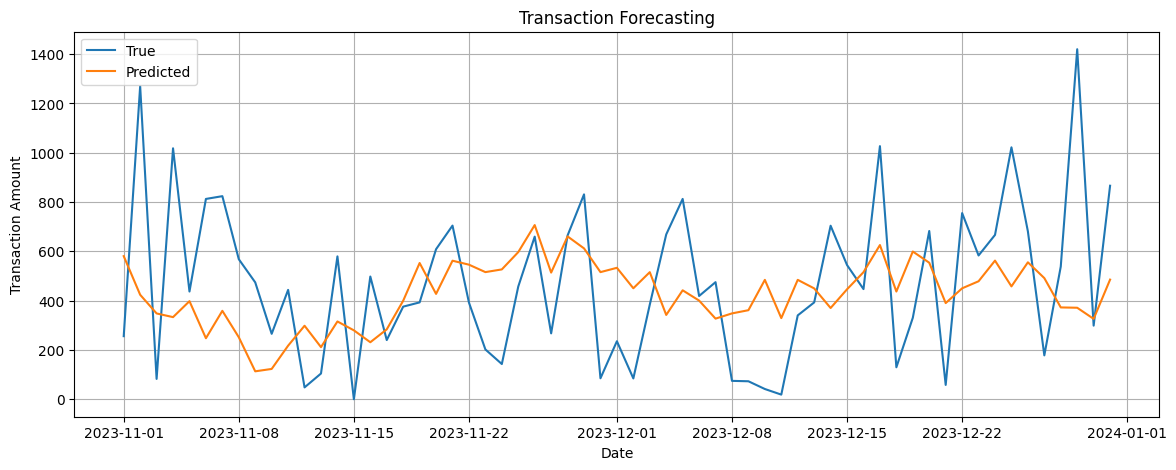

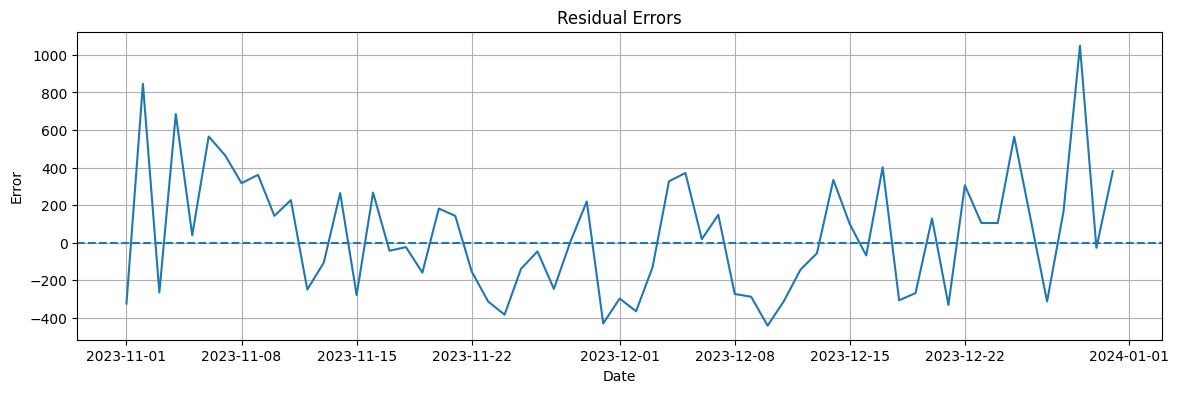

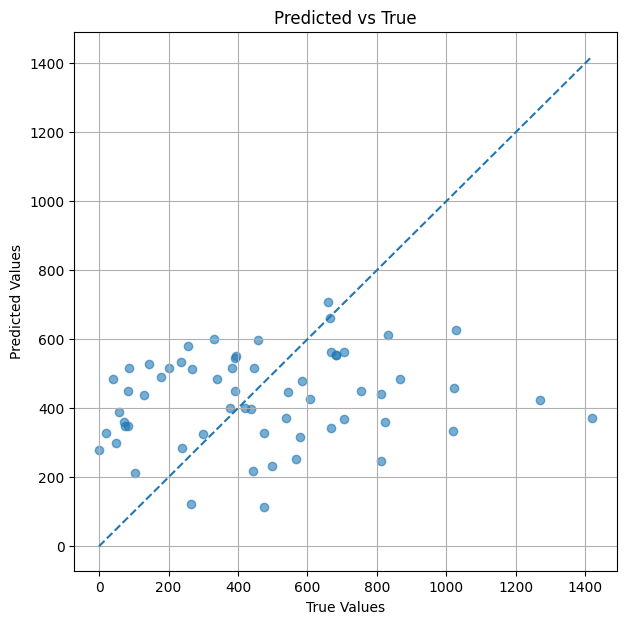

Better model found at epoch 0 with valid_loss value: 264.7677917480469.

MAE : 264.7678
RMSE: 327.5230


In [2]:
from tsai.all import *
from fastai.callback.tracker import SaveModelCallback

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler


set_seed(42, reproducible=True)


df = pd.read_csv('dataset.csv')

df = df[df['User_ID'] != 'USER_0007'].copy()
df['Location'] = df['Location'].replace('Lndn', 'London')
df = df.loc[df['Transaction_Amount'] > 0, :].copy()


df["Timestamp"] = pd.to_datetime(df["Timestamp"])


daily = (
    df[
        (df["Transaction_Type"] == "Online") &
        (df["Location"] == "London") &
        (df["Fraud_Label"] == 0)
    ]
    .groupby(df["Timestamp"].dt.date)["Transaction_Amount"]
    .sum()
    .reset_index()
)

daily.columns = ["Date", "Total_Transaction"]

daily["Date"] = pd.to_datetime(daily["Date"])


daily = (
    daily.set_index("Date")
    .asfreq("D", fill_value=0)
    .reset_index()
)


# dodatni featurei

daily['dayofweek'] = daily['Date'].dt.dayofweek

daily['weekday_sin'] = np.sin(
    2 * np.pi * daily['dayofweek'] / 7
)

daily['weekday_cos'] = np.cos(
    2 * np.pi * daily['dayofweek'] / 7
)

daily['is_weekend'] = (
    daily['dayofweek'] >= 5
).astype(float)

daily['month'] = daily['Date'].dt.month

daily['month_sin'] = np.sin(
    2 * np.pi * daily['month'] / 12
)

daily['month_cos'] = np.cos(
    2 * np.pi * daily['month'] / 12
)

daily['rolling_mean_7'] = (
    daily['Total_Transaction']
    .shift(1)
    .rolling(7)
    .mean()
)

daily['rolling_std_7'] = (
    daily['Total_Transaction']
    .shift(1)
    .rolling(7)
    .std()
)


daily['lag_1'] = daily['Total_Transaction'].shift(1)
daily['lag_7'] = daily['Total_Transaction'].shift(7)


daily['expanding_mean'] = (
    daily['Total_Transaction']
    .shift(1)
    .expanding()
    .mean()
)

daily = daily.dropna().reset_index(drop=True)



values_raw = daily["Total_Transaction"].values
weekday_sin = daily["weekday_sin"].values
weekday_cos = daily["weekday_cos"].values
is_weekend = daily["is_weekend"].values
month_sin = daily["month_sin"].values
month_cos = daily["month_cos"].values
rolling_mean_7 = daily["rolling_mean_7"].values
rolling_std_7 = daily["rolling_std_7"].values
lag_1 = daily["lag_1"].values
lag_7 = daily["lag_7"].values
expanding_mean = daily["expanding_mean"].values



# MULTICHANNEL WINDOWS
window_size = 28

X = []
y = []
dates = []

for i in range(len(values_raw) - window_size):

    signal_window = values_raw[i:i+window_size]

    sin_window = weekday_sin[i:i+window_size]

    cos_window = weekday_cos[i:i+window_size]

    weekend_window = is_weekend[i:i+window_size]

    month_sin_window = month_sin[i:i+window_size]

    month_cos_window = month_cos[i:i+window_size]
    rolling_mean_window = rolling_mean_7[i:i+window_size]

    rolling_std_window = rolling_std_7[i:i+window_size]
    lag1_window = lag_1[i:i+window_size]

    lag7_window = lag_7[i:i+window_size]
    expanding_mean_window = expanding_mean[i:i+window_size]

    sample = np.stack([
        signal_window,
        sin_window,
        cos_window,
        weekend_window,

        month_sin_window,
        month_cos_window,

        rolling_mean_window,
        rolling_std_window,

        lag1_window,
        lag7_window,
        expanding_mean_window

    ])

    X.append(sample)

    y.append(values_raw[i+window_size])

    dates.append(daily["Date"].iloc[i+window_size])

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

dates = pd.to_datetime(dates)

print("X shape:", X.shape)
print("y shape:", y.shape)



split_date = pd.Timestamp('2023-11-01')

train_idx = np.where(dates < split_date)[0]
test_idx = np.where(dates >= split_date)[0]

splits = (train_idx, test_idx)



print("Train samples:", len(train_idx))
print("Test samples:", len(test_idx))


dls = get_ts_dls(
    X,
    y,
    splits=splits,
    bs=5
)



model = HydraMultiRocketPlus(
    c_in=11,
    c_out=1,
    seq_len=window_size
)

print(model)



learn = Learner(
    dls,
    model,
    loss_func=MSELossFlat(),
    metrics=[mae, rmse],
    cbs=SaveModelCallback(
        monitor='valid_loss',
        fname='best_model'
    )
)


learn.fit_one_cycle(30, 5e-3)


preds, targets = learn.get_preds()

preds = preds.squeeze().numpy()
targets = targets.squeeze().numpy()



test_dates = dates[test_idx]

plt.figure(figsize=(14,5))

plt.plot(
    test_dates,
    targets,
    label='True'
)

plt.plot(
    test_dates,
    preds,
    label='Predicted'
)

plt.title("Transaction Forecasting")

plt.xlabel("Date")
plt.ylabel("Transaction Amount")

plt.legend()
plt.grid(True)

plt.show()


residuals = targets - preds

plt.figure(figsize=(14,4))

plt.plot(
    test_dates,
    residuals
)

plt.axhline(0, linestyle='--')

plt.title("Residual Errors")

plt.xlabel("Date")
plt.ylabel("Error")

plt.grid(True)

plt.show()


# Predicted vs True scatter plot
# Useful for spotting systematic drift:
# - points above diagonal -> overprediction
# - points below diagonal -> underprediction

preds, targets = learn.get_preds()

preds = preds.squeeze().numpy()
targets = targets.squeeze().numpy()

plt.figure(figsize=(7,7))

plt.scatter(
    targets,
    preds,
    alpha=0.6
)

# ideal diagonal
min_val = min(targets.min(), preds.min())
max_val = max(targets.max(), preds.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--'
)

plt.xlabel("True Values")
plt.ylabel("Predicted Values")

plt.title("Predicted vs True")

plt.grid(True)

plt.show()



loss, mae_val, rmse_val = learn.validate()

print(f"\nMAE : {mae_val:.4f}")
print(f"RMSE: {rmse_val:.4f}")





#### Dodatna analiza (SMAPE)
https://en.wikipedia.org/wiki/Symmetric_mean_absolute_percentage_error


Average SMAPE by Weekday
--------------------------------
weekday
Monday       87.570000
Tuesday      41.619999
Wednesday    61.180000
Thursday     90.059998
Friday       80.309998
Saturday     57.240002
Sunday       57.139999
Name: smape, dtype: float32


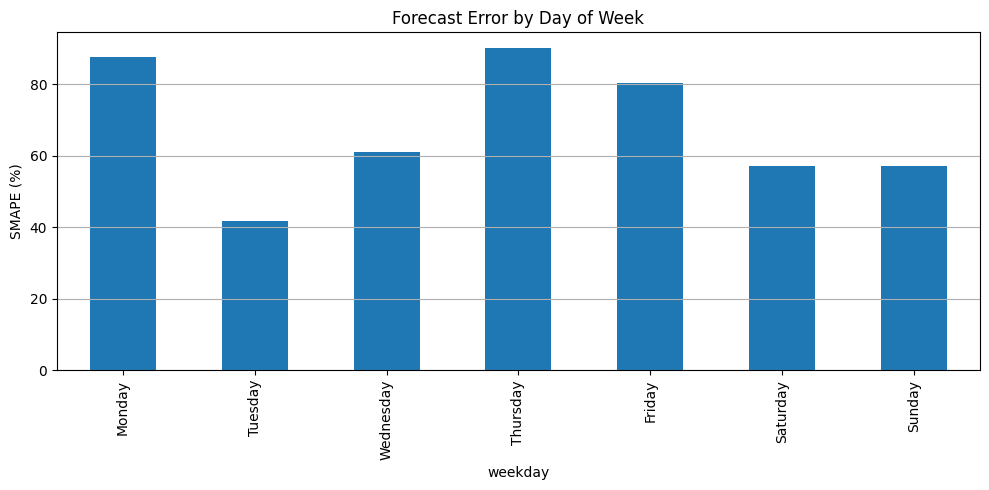


Weekly Average SMAPE
--------------------------------
year_week
2023-44    100.599998
2023-45     76.680000
2023-46     81.050003
2023-47     50.389999
2023-48     65.550003
2023-49     65.269997
2023-50     70.239998
2023-51     64.910004
2023-52     52.790001
2023-53     56.360001
Name: smape, dtype: float32


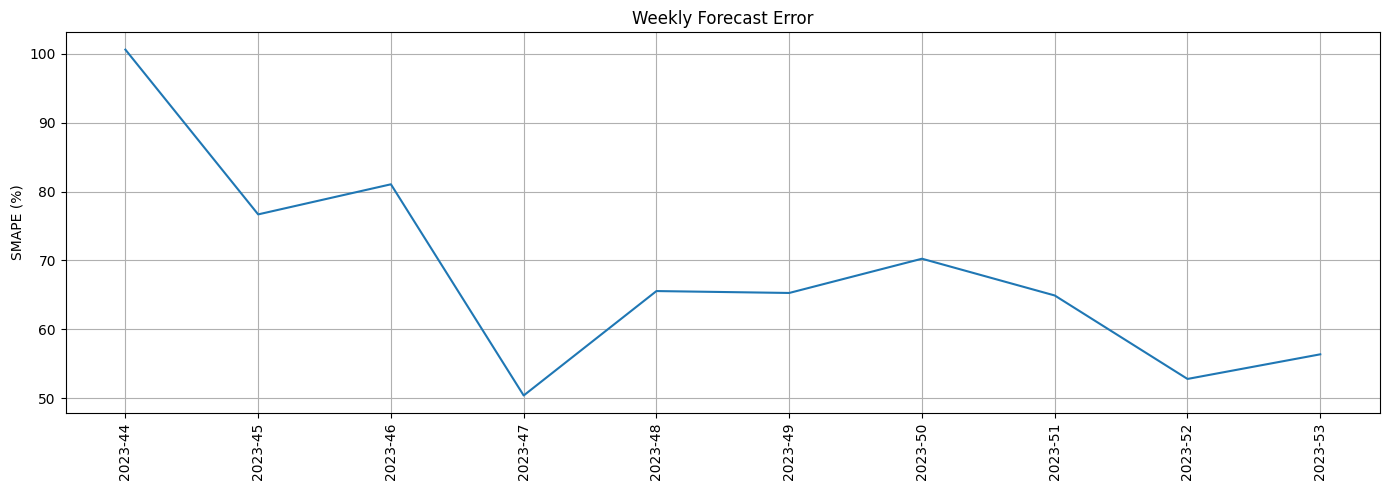


Worst Prediction Days
--------------------------------
      date        true       pred      smape  signed_smape
2023-11-15    0.000000 279.519989 200.000000    200.000000
2023-12-11   18.690001 329.130005 178.509995    178.509995
2023-12-10   41.459999 484.299988 168.460007    168.460007
2023-12-21   58.000000 390.119995 148.229996    148.229996
2023-11-12   47.970001 298.170013 144.570007    144.570007
2023-11-30   84.919998 515.739990 143.449997    143.449997
2023-12-02   84.349998 450.230011 136.880005    136.880005
2023-12-09   72.830002 361.250000 132.889999    132.889999
2023-12-08   74.500000 348.200012 129.500000    129.500000
2023-11-03   82.400002 348.070007 123.430000    123.430000
2023-11-09  474.089996 113.209999 122.889999   -122.889999
2023-12-29 1420.180054 371.179993 117.120003   -117.120003
2023-11-24  142.770004 526.729980 114.699997    114.699997
2023-12-18  129.539993 436.989990 108.540001    108.540001
2023-11-06  812.690002 247.509995 106.620003   -106.620003


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



preds, targets = learn.get_preds()

preds = preds.squeeze().numpy()
targets = targets.squeeze().numpy()

test_dates = pd.to_datetime(dates[test_idx])


df_eval = pd.DataFrame({
    "date": test_dates,
    "true": targets,
    "pred": preds
})


df_eval["abs_error"] = np.abs(
    df_eval["pred"] - df_eval["true"]
)

df_eval["signed_error"] = (
    df_eval["pred"] - df_eval["true"]
)

# ========================================
# SMAPE (stable percentage metric)
# ========================================

eps = 1e-8

df_eval["smape"] = (
    100
    * np.abs(df_eval["pred"] - df_eval["true"])
    / (
        (
            np.abs(df_eval["true"])
            + np.abs(df_eval["pred"])
        ) / 2
        + eps
    )
)

df_eval["signed_smape"] = (
    100
    * (
        df_eval["pred"] - df_eval["true"]
    )
    / (
        (
            np.abs(df_eval["true"])
            + np.abs(df_eval["pred"])
        ) / 2
        + eps
    )
)


df_eval["weekday"] = (
    df_eval["date"].dt.day_name()
)

df_eval["year_week"] = (
    df_eval["date"].dt.strftime("%Y-%U")
)

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]



weekday_stats = (
    df_eval
    .groupby("weekday")["smape"]
    .mean()
    .reindex(weekday_order)
)

print("\nAverage SMAPE by Weekday")
print("--------------------------------")
print(weekday_stats.round(2))



plt.figure(figsize=(10,5))

weekday_stats.plot(kind="bar")

plt.ylabel("SMAPE (%)")

plt.title(
    "Forecast Error by Day of Week"
)

plt.grid(True, axis="y")

plt.tight_layout()

plt.show()


weekly_stats = (
    df_eval
    .groupby("year_week")["smape"]
    .mean()
)

print("\nWeekly Average SMAPE")
print("--------------------------------")
print(weekly_stats.round(2))


plt.figure(figsize=(14,5))

plt.plot(
    weekly_stats.index,
    weekly_stats.values
)

plt.xticks(rotation=90)

plt.ylabel("SMAPE (%)")

plt.title(
    "Weekly Forecast Error"
)

plt.grid(True)

plt.tight_layout()

plt.show()



worst_days = (
    df_eval
    .sort_values("smape", ascending=False)
    .head(20)
)

print("\nWorst Prediction Days")
print("--------------------------------")

print(
    worst_days[
        [
            "date",
            "true",
            "pred",
            "smape",
            "signed_smape"
        ]
    ]
    .round(2)
    .to_string(index=False)
)

# ========================================
# SYSTEMATIC BIAS
# ========================================

mean_signed_smape = (
    df_eval["signed_smape"].mean()
)

print("\nMean Signed SMAPE")
print("--------------------------------")
print(round(mean_signed_smape, 2), "%")

if mean_signed_smape > 0:
    print("Model tends to OVERpredict.")
else:
    print("Model tends to UNDERpredict.")


# ========================================
# LOW VALUE INSPECTION
# ========================================

print("\nLowest True Values")
print("--------------------------------")

print(
    df_eval
    .sort_values("true")
    .head(20)[
        [
            "date",
            "true",
            "pred",
            "smape"
        ]
    ]
    .round(2)
    .to_string(index=False)
)

### B. z-scale (da budu iznosi u skladu s sin, cos rasponom)

X shape: (330, 11, 28)
y shape: (330,)
Train samples: 269
Test samples: 61
HydraMultiRocketPlus(
  (backbone): HydraMultiRocketBackbonePlus(
    (hydra): HydraBackbonePlus()
    (multirocket): MultiRocketBackbonePlus(
      (branch_x): MultiRocketFeaturesPlus()
      (branch_x_diff): MultiRocketFeaturesPlus()
    )
  )
  (head): Sequential(
    (0): fastai.layers.Flatten(full=False)
    (1): BatchNorm1d(51776, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Linear(in_features=51776, out_features=1, bias=True)
  )
)


epoch,train_loss,valid_loss,mae,_rmse,time
0,4.323721,2.386993,1.242987,1.544990,00:01
1,47.750439,34.644005,4.387170,5.885916,00:01
2,149.948181,178.391968,11.386050,13.356345,00:01
3,136.453751,35.413498,5.025261,5.950924,00:01
4,110.554245,37.274994,5.092693,6.105325,00:01
5,76.230194,12.671964,2.938250,3.559770,00:01
6,44.005371,19.077721,3.659607,4.367805,00:01
7,24.888918,8.695418,2.534027,2.948799,00:01
8,14.903333,9.369353,2.617311,3.060940,00:01
9,9.525022,10.016465,2.685838,3.164880,00:01


Better model found at epoch 0 with valid_loss value: 2.386993169784546.


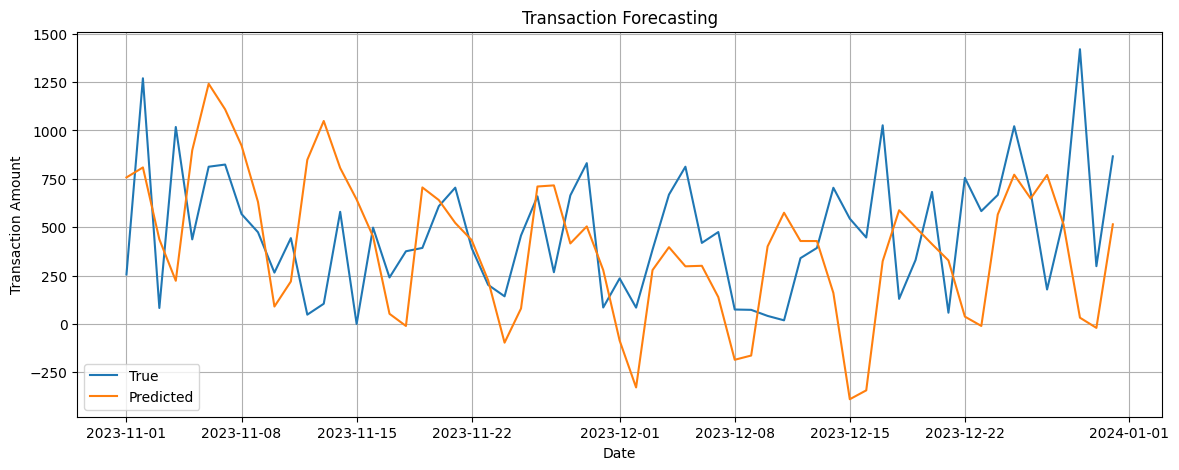

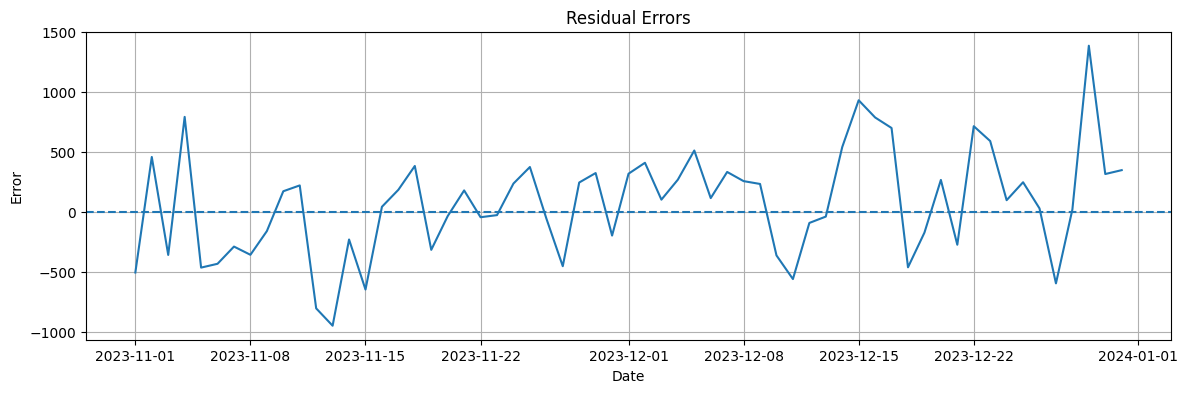

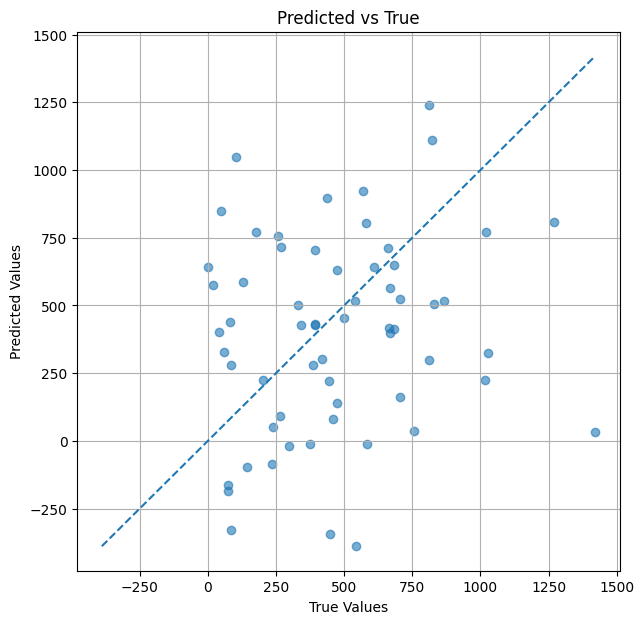


MAE : 361.20
RMSE: 448.96


In [3]:
from tsai.all import *
from fastai.callback.tracker import SaveModelCallback

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler


set_seed(42, reproducible=True)


df = pd.read_csv('dataset.csv')

df = df[df['User_ID'] != 'USER_0007'].copy()
df['Location'] = df['Location'].replace('Lndn', 'London')
df = df.loc[df['Transaction_Amount'] > 0, :].copy()


df["Timestamp"] = pd.to_datetime(df["Timestamp"])


daily = (
    df[
        (df["Transaction_Type"] == "Online") &
        (df["Location"] == "London") &
        (df["Fraud_Label"] == 0)
    ]
    .groupby(df["Timestamp"].dt.date)["Transaction_Amount"]
    .sum()
    .reset_index()
)

daily.columns = ["Date", "Total_Transaction"]

daily["Date"] = pd.to_datetime(daily["Date"])


daily = (
    daily.set_index("Date")
    .asfreq("D", fill_value=0)
    .reset_index()
)


# FEATS

daily['dayofweek'] = daily['Date'].dt.dayofweek

daily['weekday_sin'] = np.sin(
    2 * np.pi * daily['dayofweek'] / 7
)

daily['weekday_cos'] = np.cos(
    2 * np.pi * daily['dayofweek'] / 7
)

daily['is_weekend'] = (
    daily['dayofweek'] >= 5
).astype(float)

daily['month'] = daily['Date'].dt.month

daily['month_sin'] = np.sin(
    2 * np.pi * daily['month'] / 12
)

daily['month_cos'] = np.cos(
    2 * np.pi * daily['month'] / 12
)

daily['rolling_mean_7'] = (
    daily['Total_Transaction']
    .shift(1)
    .rolling(7)
    .mean()
)

daily['rolling_std_7'] = (
    daily['Total_Transaction']
    .shift(1)
    .rolling(7)
    .std()
)

daily['lag_1'] = (
    daily['Total_Transaction']
    .shift(1)
)

daily['lag_7'] = (
    daily['Total_Transaction']
    .shift(7)
)

daily['expanding_mean'] = (
    daily['Total_Transaction']
    .shift(1)
    .expanding()
    .mean()
)

daily = daily.dropna().reset_index(drop=True)



split_date = pd.Timestamp('2023-11-01')

train_mask = (
    daily["Date"] < split_date
)

# ============================================
# NORMALIZATION
# ============================================

scale_cols = [
    "Total_Transaction",
    "rolling_mean_7",
    "rolling_std_7",
    "lag_1",
    "lag_7",
    "expanding_mean"
]

scaler = StandardScaler()

# FIT ONLY ON TRAIN

daily.loc[train_mask, scale_cols] = (
    scaler.fit_transform(
        daily.loc[train_mask, scale_cols]
    )
)

# TRANSFORM TEST

daily.loc[~train_mask, scale_cols] = (
    scaler.transform(
        daily.loc[~train_mask, scale_cols]
    )
)



values_raw = (
    daily["Total_Transaction"].values
)

weekday_sin = (
    daily["weekday_sin"].values
)

weekday_cos = (
    daily["weekday_cos"].values
)

is_weekend = (
    daily["is_weekend"].values
)

month_sin = (
    daily["month_sin"].values
)

month_cos = (
    daily["month_cos"].values
)

rolling_mean_7 = (
    daily["rolling_mean_7"].values
)

rolling_std_7 = (
    daily["rolling_std_7"].values
)

lag_1 = (
    daily["lag_1"].values
)

lag_7 = (
    daily["lag_7"].values
)

expanding_mean = (
    daily["expanding_mean"].values
)

daily = daily.dropna().reset_index(drop=True)



values_raw = daily["Total_Transaction"].values
weekday_sin = daily["weekday_sin"].values
weekday_cos = daily["weekday_cos"].values
is_weekend = daily["is_weekend"].values
month_sin = daily["month_sin"].values
month_cos = daily["month_cos"].values
rolling_mean_7 = daily["rolling_mean_7"].values
rolling_std_7 = daily["rolling_std_7"].values
lag_1 = daily["lag_1"].values
lag_7 = daily["lag_7"].values
expanding_mean = daily["expanding_mean"].values



# MULTICHANNEL WINDOWS
window_size = 28

X = []
y = []
dates = []

for i in range(len(values_raw) - window_size):

    signal_window = values_raw[i:i+window_size]

    sin_window = weekday_sin[i:i+window_size]

    cos_window = weekday_cos[i:i+window_size]

    weekend_window = is_weekend[i:i+window_size]

    month_sin_window = month_sin[i:i+window_size]

    month_cos_window = month_cos[i:i+window_size]
    rolling_mean_window = rolling_mean_7[i:i+window_size]

    rolling_std_window = rolling_std_7[i:i+window_size]
    lag1_window = lag_1[i:i+window_size]

    lag7_window = lag_7[i:i+window_size]
    expanding_mean_window = expanding_mean[i:i+window_size]

    sample = np.stack([
        signal_window,
        sin_window,
        cos_window,
        weekend_window,

        month_sin_window,
        month_cos_window,

        rolling_mean_window,
        rolling_std_window,

        lag1_window,
        lag7_window,
        expanding_mean_window

    ])

    X.append(sample)

    y.append(values_raw[i+window_size])

    dates.append(daily["Date"].iloc[i+window_size])

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

dates = pd.to_datetime(dates)

print("X shape:", X.shape)
print("y shape:", y.shape)



split_date = pd.Timestamp('2023-11-01')

train_idx = np.where(dates < split_date)[0]
test_idx = np.where(dates >= split_date)[0]

splits = (train_idx, test_idx)



print("Train samples:", len(train_idx))
print("Test samples:", len(test_idx))


dls = get_ts_dls(
    X,
    y,
    splits=splits,
    bs=5
)



model = HydraMultiRocketPlus(
    c_in=11,
    c_out=1,
    seq_len=window_size
)

print(model)



learn = Learner(
    dls,
    model,
    loss_func=MSELossFlat(),
    metrics=[mae, rmse],
    cbs=SaveModelCallback(
        monitor='valid_loss',
        fname='best_model'
    )
)


learn.fit_one_cycle(10, 1e-3)


preds, targets = learn.get_preds()


target_mean = scaler.mean_[0]
target_std = scaler.scale_[0]

preds_real = (
    preds * target_std
    + target_mean
)

targets_real = (
    targets * target_std
    + target_mean
)

preds_real = preds_real.squeeze().numpy()
targets_real = targets_real.squeeze().numpy()



test_dates = dates[test_idx]

plt.figure(figsize=(14,5))

plt.plot(
    test_dates,
    targets_real,
    label='True'
)

plt.plot(
    test_dates,
    preds_real,
    label='Predicted'
)

plt.title("Transaction Forecasting")

plt.xlabel("Date")
plt.ylabel("Transaction Amount")

plt.legend()
plt.grid(True)

plt.show()


residuals = targets_real - preds_real

plt.figure(figsize=(14,4))

plt.plot(
    test_dates,
    residuals
)

plt.axhline(0, linestyle='--')

plt.title("Residual Errors")

plt.xlabel("Date")
plt.ylabel("Error")

plt.grid(True)

plt.show()




plt.figure(figsize=(7,7))

plt.scatter(
    targets_real,
    preds_real,
    alpha=0.6
)

# ideal diagonal
min_val = min(targets_real.min(), preds_real.min())
max_val = max(targets_real.max(), preds_real.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--'
)

plt.xlabel("True Values")
plt.ylabel("Predicted Values")

plt.title("Predicted vs True")

plt.grid(True)

plt.show()


from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error


mae_real = mean_absolute_error(
    targets_real,
    preds_real
)

rmse_real = np.sqrt(
    mean_squared_error(
        targets_real,
        preds_real
    )
)

print(f"\nMAE : {mae_real:.2f}")
print(f"RMSE: {rmse_real:.2f}")




#### SMAPE


Average SMAPE by Weekday
--------------------------------
weekday
Monday        87.010002
Tuesday       37.419998
Wednesday     69.019997
Thursday      64.419998
Friday       170.639999
Saturday     170.690002
Sunday        75.279999
Name: smape, dtype: float32


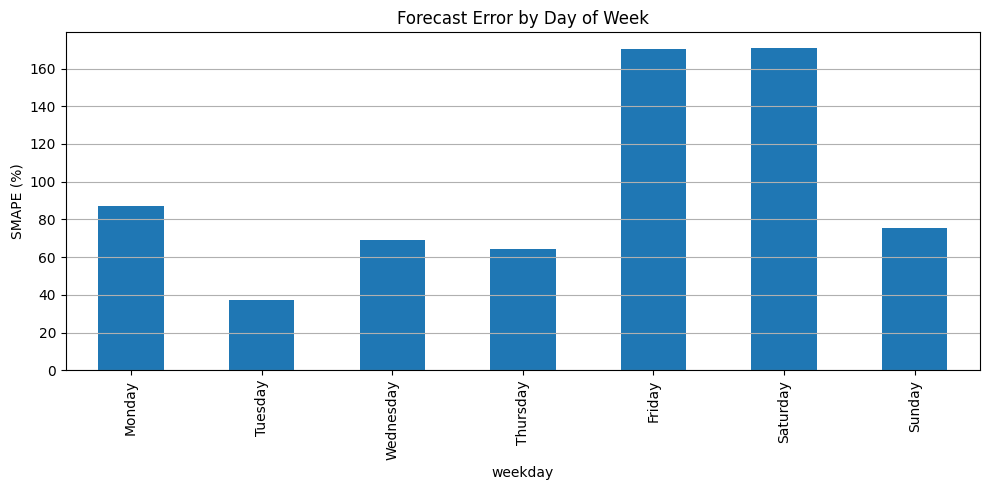


Weekly Average SMAPE
--------------------------------
year_week
2023-44    102.010002
2023-45     54.650002
2023-46    130.449997
2023-47     64.730003
2023-48    100.029999
2023-49    102.580002
2023-50    129.639999
2023-51    120.379997
2023-52     81.389999
2023-53     50.869999
Name: smape, dtype: float32


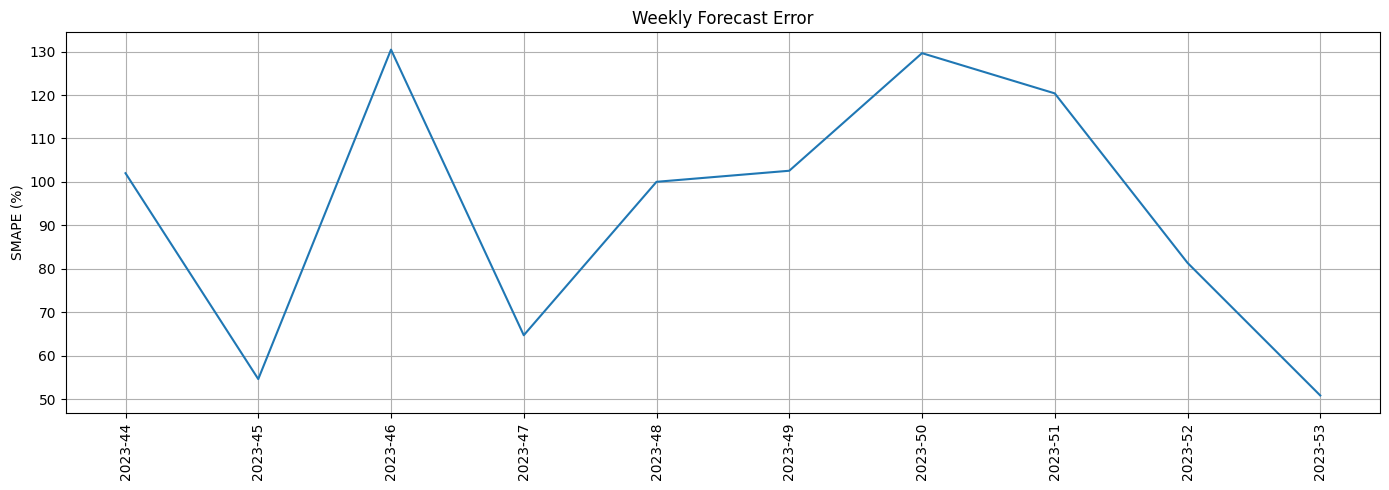


Worst Prediction Days
--------------------------------
      date        true        pred      smape  signed_smape
2023-11-15    0.000000  643.380005 200.000000    200.000000
2023-11-18  375.640015  -10.460000 200.000000   -200.000000
2023-11-24  142.770004  -96.809998 200.000000   -200.000000
2023-12-02   84.349998 -328.320007 200.000000   -200.000000
2023-12-01  235.270004  -86.309998 200.000000   -200.000000
2023-12-08   74.500000 -185.279999 200.000000   -200.000000
2023-12-30  298.570007  -20.360001 200.000000   -200.000000
2023-12-23  583.299988  -10.380000 200.000000   -200.000000
2023-12-15  544.299988 -389.230011 200.000000   -200.000000
2023-12-09   72.830002 -163.389999 200.000000   -200.000000
2023-12-16  446.839996 -343.390015 200.000000   -200.000000
2023-12-29 1420.180054   32.220001 191.130005   -191.130005
2023-12-11   18.690001  574.880005 187.410004    187.410004
2023-12-22  755.250000   37.830002 180.919998   -180.919998
2023-11-12   47.970001  848.349976 178.58999

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



preds, targets = learn.get_preds()

target_mean = scaler.mean_[0]
target_std = scaler.scale_[0]

preds_real = (
    preds * target_std
    + target_mean
)

targets_real = (
    targets * target_std
    + target_mean
)

preds_real = preds_real.squeeze().numpy()
targets_real = targets_real.squeeze().numpy()


test_dates = pd.to_datetime(dates[test_idx])


df_eval = pd.DataFrame({
    "date": test_dates,
    "true": targets_real,
    "pred": preds_real
})


df_eval["abs_error"] = np.abs(
    df_eval["pred"] - df_eval["true"]
)

df_eval["signed_error"] = (
    df_eval["pred"] - df_eval["true"]
)



eps = 1e-8

df_eval["smape"] = (
    100
    * np.abs(df_eval["pred"] - df_eval["true"])
    / (
        (
            np.abs(df_eval["true"])
            + np.abs(df_eval["pred"])
        ) / 2
        + eps
    )
)

df_eval["signed_smape"] = (
    100
    * (
        df_eval["pred"] - df_eval["true"]
    )
    / (
        (
            np.abs(df_eval["true"])
            + np.abs(df_eval["pred"])
        ) / 2
        + eps
    )
)


df_eval["weekday"] = (
    df_eval["date"].dt.day_name()
)

df_eval["year_week"] = (
    df_eval["date"].dt.strftime("%Y-%U")
)

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]



weekday_stats = (
    df_eval
    .groupby("weekday")["smape"]
    .mean()
    .reindex(weekday_order)
)

print("\nAverage SMAPE by Weekday")
print("--------------------------------")
print(weekday_stats.round(2))



plt.figure(figsize=(10,5))

weekday_stats.plot(kind="bar")

plt.ylabel("SMAPE (%)")

plt.title(
    "Forecast Error by Day of Week"
)

plt.grid(True, axis="y")

plt.tight_layout()

plt.show()


weekly_stats = (
    df_eval
    .groupby("year_week")["smape"]
    .mean()
)

print("\nWeekly Average SMAPE")
print("--------------------------------")
print(weekly_stats.round(2))


plt.figure(figsize=(14,5))

plt.plot(
    weekly_stats.index,
    weekly_stats.values
)

plt.xticks(rotation=90)

plt.ylabel("SMAPE (%)")

plt.title(
    "Weekly Forecast Error"
)

plt.grid(True)

plt.tight_layout()

plt.show()



worst_days = (
    df_eval
    .sort_values("smape", ascending=False)
    .head(20)
)

print("\nWorst Prediction Days")
print("--------------------------------")

print(
    worst_days[
        [
            "date",
            "true",
            "pred",
            "smape",
            "signed_smape"
        ]
    ]
    .round(2)
    .to_string(index=False)
)



mean_signed_smape = (
    df_eval["signed_smape"].mean()
)

print("\nMean Signed SMAPE")
print("--------------------------------")
print(round(mean_signed_smape, 2), "%")

if mean_signed_smape > 0:
    print("Model tends to OVERpredict.")
else:
    print("Model tends to UNDERpredict.")




print("\nLowest True Values")
print("--------------------------------")

print(
    df_eval
    .sort_values("true")
    .head(20)[
        [
            "date",
            "true",
            "pred",
            "smape"
        ]
    ]
    .round(2)
    .to_string(index=False)
)